# 02 — Phase 1 Clustering on Pre-Computed FMA Features

Run notebook 01 first to generate `models/fma_small_features.pkl`.

**Goal**: Cluster the FMA tracks using **Leiden community detection on a k-NN graph** built from hand-crafted audio features, then build a **standardized** cosine similarity index.

- Clustering runs on the PCA/embedding space; 2D UMAP is **visualization only**.
- `resolution` is the one knob — sweep it and pick with the genre-free metrics.
- Genre labels are **displayed** for interpretation only — never a training signal or quality metric.

In [ ]:
import sys
sys.path.insert(0, '..')  # optional now that anther_ml is `pip install -e .`

import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from collections import Counter

from anther_ml.cluster import (
    fit_clusters_leiden, assign_cluster_knn,
    save_leiden, load_leiden, resolution_sweep,
)
from anther_ml.similarity import SongIndex
from anther_ml.features import extract_librosa_features, align_to_corpus, fma_feature_columns
from anther_ml import eval as ev

print('imports ok')

## Load saved feature data

In [ ]:
with open('../models/fma_small_features.pkl', 'rb') as f:
    data = pickle.load(f)

X = data['X']                      # (N, 518)
genre_labels = data['genre_labels'] # list of strings
track_ids    = data['track_ids']
track_names  = data['track_names']
artist_names = data['artist_names']

print(f'Feature matrix: {X.shape}')
print(f'Genres: {Counter(genre_labels).most_common(5)}')

# Sanity checks (Workstreams B & C)
assert X.shape[1] == len(fma_feature_columns()), 'feature count != FMA 518-dim schema'
if X.shape[0] > 20000:
    print(f'\n⚠️  X has {X.shape[0]} rows — that is FMA-large, not fma_small (8000).')
    print('   The old subset filter matched everything; re-run notebook 01 (now fixed)')
    print('   to regenerate models/fma_small_features.pkl at 8k before clustering.')

## Fit Leiden community detection

First sweep the `resolution` knob (fast — skips the 2D UMAP) to see the size
distribution at each setting, then fit at a chosen resolution. The k-NN graph is
built on the standardized PCA embedding with a cosine metric; every track gets a
community, so there is no giant catch-all cluster and no noise bucket.

In [ ]:
# Sweep the resolution knob — low → few broad clusters, high → many fine ones
sweep = resolution_sweep(
    X, resolutions=(0.2, 0.5, 1.0, 1.5, 2.0),
    n_pca_components=100, standardize=True,
)
print(f'\n{"res":>5} | {"clusters":>8} | {"largest %":>9} | {"noise %":>7}')
print('-' * 40)
for s in sweep:
    print(f'{s["resolution"]:>5} | {s["n_clusters"]:>8} | '
          f'{s["largest_cluster_frac"]*100:>8.1f}% | {s["noise_frac"]*100:>6.1f}%')

# ── Pick the resolution after inspecting the sweep above ──────────────────────
RESOLUTION = 1.0
# ─────────────────────────────────────────────────────────────────────────────
out = fit_clusters_leiden(
    X, resolution=RESOLUTION, n_pca_components=100, standardize=True,
)
labels       = out['labels']
embedding_2d = out['embedding_2d']   # 2D UMAP — visualization only
scaler       = out['scaler']
pca          = out['pca']
reducer_2d   = out['reducer_2d']

n_clusters = out['diagnostics']['n_clusters']
print(f'\nClusters found: {n_clusters}   (largest '
      f'{out["diagnostics"]["largest_cluster_frac"]*100:.1f}% of tracks)')

## Evaluate (genre-free): size distribution + silhouette

Quality is judged without genre. We report the cluster size distribution and the
silhouette on the *clustering-space* embedding (not the 2D viz). Genre composition
is printed underneath for interpretation only — it does not drive any decision.

In [ ]:
# Genre-free diagnostics on the clustering-space embedding
diag = out['diagnostics']
sil  = ev.silhouette(out['clustering_space'], labels)

print(f'n_clusters   : {diag["n_clusters"]}')
print(f'noise %      : {diag["noise_frac"]*100:.1f}%')
print(f'largest %    : {diag["largest_cluster_frac"]*100:.1f}%')
print(f'silhouette   : {sil:.4f}   [higher is better; on the clustering embedding]')
if diag['largest_cluster_frac'] > 0.60:
    print('⚠️  largest cluster > 60% — likely degenerate; try a higher resolution')

print(f'\n{"Cluster":>8} | {"Size":>6}')
print('-' * 20)
for cid, size in sorted(diag['sizes'].items()):
    print(f'{cid:>8} | {size:>6}')

# Genre composition per cluster — DISPLAY ONLY (never used as a metric)
print('\nGenre composition per cluster (display only):')
for cid in sorted(set(labels)):
    genres = [g for g, l in zip(genre_labels, labels) if l == cid]
    top = Counter(genres).most_common(3)
    print(f'  C{cid} (n={len(genres)}): ' + ', '.join(f'{g}×{n}' for g, n in top))

## Visualize: 2D UMAP coloured by genre

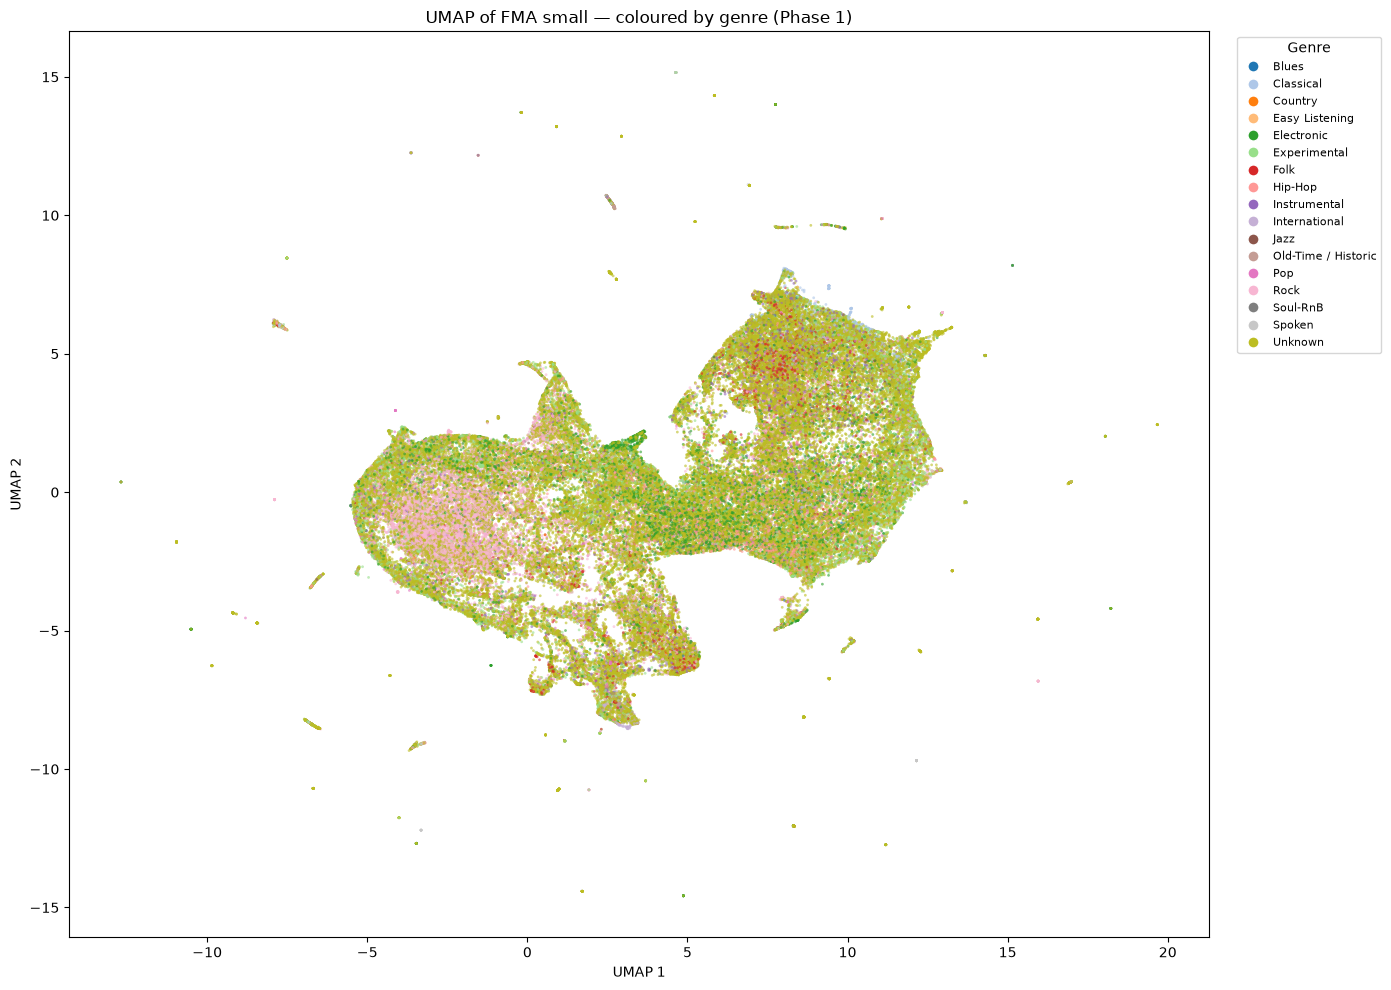

Saved to models/umap_phase1.png


In [8]:
unique_genres = sorted(set(genre_labels))
palette = sns.color_palette('tab20', n_colors=len(unique_genres))
genre_to_color = {g: palette[i] for i, g in enumerate(unique_genres)}
colors = [genre_to_color[g] for g in genre_labels]

fig, ax = plt.subplots(figsize=(14, 10))
scatter = ax.scatter(
    embedding_2d[:, 0], embedding_2d[:, 1],
    c=colors, s=4, alpha=0.6, linewidths=0
)
# Legend
handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=genre_to_color[g], markersize=8, label=g)
    for g in unique_genres
]
ax.legend(handles=handles, title='Genre', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.set_title('UMAP of FMA small — coloured by genre (Phase 1)')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
plt.tight_layout()
plt.savefig('../models/umap_phase1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to models/umap_phase1.png')

## Visualize: 2D UMAP coloured by Leiden community

Reminder: the 2D UMAP is **only** for this picture — the communities were found in
the higher-dim embedding, not here.

In [ ]:
fig, ax = plt.subplots(figsize=(14, 10))

# Leiden assigns every track to a community — no noise bucket.
cluster_ids = sorted(set(labels))
palette2 = sns.color_palette('husl', n_colors=len(cluster_ids))
for cid, color in zip(cluster_ids, palette2):
    mask = labels == cid
    ax.scatter(
        embedding_2d[mask, 0], embedding_2d[mask, 1],
        c=[color], s=4, alpha=0.7, label=f'C{cid}', linewidths=0
    )

ax.set_title(f'Leiden communities ({n_clusters} found) — 2D UMAP is viz only')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig('../models/clusters_phase1.png', dpi=150, bbox_inches='tight')
plt.show()

## Save the pipeline and similarity index

In [ ]:
# Save the Leiden pipeline (labels, scaler, pca, clustering_space, reducer_2d, params)
save_leiden('../models/pipeline_phase1.pkl', out)

# Build and save the similarity index.
#  * standardize=True fixes the scale-domination bug (Workstream A) — pass RAW X,
#    the index z-scores columns internally and persists the stats.
#  * config makes the index self-describing so incompatible indices can't be mixed.
metadata = [
    {'track_id': tid, 'name': name, 'artist': artist, 'genre': genre, 'cluster': int(cid)}
    for tid, name, artist, genre, cid
    in zip(track_ids, track_names, artist_names, genre_labels, labels)
]
index = SongIndex(
    X, metadata, standardize=True,
    config={'phase': 1, 'source': 'fma_small', 'features': 'librosa-518',
            'resolution': RESOLUTION},
)
index.save('../models/index_phase1')

# 2D embedding + labels for later notebooks
np.save('../models/embedding_2d_phase1.npy', embedding_2d)
np.save('../models/labels_phase1.npy', labels)

print('Saved Leiden pipeline, standardized index, and 2D embedding.')

# Quick genre-free scorecard on the index we just built
card = ev.build_scorecard(index, labels=labels)
print(f"\nsilhouette={card['silhouette']:.3f}  "
      f"n_clusters={card['size_distribution']['n_clusters']}  "
      f"largest={card['size_distribution']['largest_cluster_frac']:.1%}")

## Test: assign a personal MP3 to a community

Put the path to any MP3 below. The cell extracts FMA-compatible features (as a
labeled Series), aligns them to the corpus column order (with a hard assertion),
assigns the song to a Leiden community by k-NN vote, and lists the top-10 nearest
tracks. Note the query vector is passed **raw** — the index standardizes it
against the corpus stats internally.

In [ ]:
# ── CHANGE THIS ──────────────────────────────────────────────────────────────
MY_SONG = '/Users/mwilliams/Downloads/icy_.mp3'
# ─────────────────────────────────────────────────────────────────────────────

pipe  = load_leiden('../models/pipeline_phase1.pkl')
index = SongIndex.load('../models/index_phase1')

print('Extracting features...')
series = extract_librosa_features(MY_SONG)                 # labeled Series (FMA order)
vec    = align_to_corpus(series, fma_feature_columns())    # asserts alignment (Workstream B)

# Assign to a Leiden community by k-NN vote — same scale/PCA transform as the corpus
cluster_id, confidence = assign_cluster_knn(
    vec, pipe['clustering_space'], pipe['labels'],
    scaler=pipe['scaler'], pca=pipe['pca'], k=pipe['n_neighbors'],
)
print(f'\nCluster assignment: {cluster_id}  (confidence: {confidence:.2f})')

# Nearest neighbors — pass the RAW aligned vec; SongIndex standardizes internally.
print('\nTop 10 nearest FMA tracks:')
for r in index.query(vec, top_k=10):
    print(f"  [{r['rank']:2}] score={r['score']:.4f}  {r['artist']} — {r['name']}  ({r['genre']})")

In [ ]:
# Project the new song into the SAME 2D space as the corpus:
#   scale → pca → reducer_2d.transform   (never use raw high-dim UMAP dims)
Xq = pipe['scaler'].transform(vec.reshape(1, -1))
if pipe['pca'] is not None:
    Xq = pipe['pca'].transform(Xq)
song_2d = pipe['reducer_2d'].transform(Xq)

fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(embedding_2d[:, 0], embedding_2d[:, 1], c=colors, s=3, alpha=0.4, linewidths=0)
ax.scatter(song_2d[0, 0], song_2d[0, 1], c='red', s=120, zorder=5,
           label='Your song', edgecolors='black')
ax.legend()
ax.set_title('Your song on the FMA feature map (Phase 1, Leiden)')
plt.tight_layout()
plt.show()